# Exercises XP Gold
Last Updated: June 10th, 2025

## 👩‍🏫 👩🏿‍🏫 What You’ll learn
How to implement and train different types of recurrent neural networks (RNN, GRU, LSTM) using PyTorch.
How to preprocess and load datasets for sequence-based tasks.
How to evaluate the performance of a model using accuracy metrics.
How to use PyTorch’s DataLoader and Dataset classes for efficient data handling.


## 🛠️ What you will create
A custom dataset class for loading and preprocessing the MNIST dataset.
Three different neural network models: SimpleRNN, SimpleGRU, and SimpleLSTM.
A training loop to train the models on the MNIST dataset.
A function to check the accuracy of the trained models on both training and test datasets.


## Dataset
You can find the dataset here : MNIST in CSV.



All “Part 1,” “Part 2,” etc., sections comprise one comprehensive exercise and are meant to be tackled sequentially as a single, continuous task.

## Part 1 : Setting Up the Environment
Install the necessary libraries, including PyTorch, torchvision, and pandas.
Define the hyperparameters for the model, such as input size, hidden size, sequence length, and learning rate.
Set up the device (CPU or GPU) for training the model.

## Partie 1 : Configuration de l’environnement

In [2]:
!pip install torch torchvision


  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2025.5.1-py3-none-any.whl.metadata (11 kB)
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   - -------------------------------------- 8.0/216.1 MB 170.8 MB/s eta 0:00:02
   --- ----------------------------------- 18.9/216.1 MB 217.7 MB/s eta 0:00:01
   --- ----------------------------------- 19.9/216.1 MB 217.7 MB/s eta 0:00:01
   ---- ---------------------------------- 27.6/216.1 MB 108.8 MB/s eta 0:00:02
   ------ -------------------------------- 35.6/216.1 MB 217.7 MB/s eta 0:00:01
   ------- ------------------------------- 41.6/216.1 MB 165.0 MB/s eta 0:00:02
   -------- ------------------------------ 47.8/216.1 MB 162.4 MB/s eta 0:00:02
   ---------- ---------------------------- 55.6/216.1 MB 165.0 MB/s eta 0:00:01
   ----------- --------------------------- 64.7/216.1 MB 165.0 MB/s eta 0:00:01
   -------------


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# PARTIE 1 : Configuration de l'environnement

# 1. Installation des bibliothèques nécessaires (déjà installées dans la plupart des environnements comme Colab ou Jupyter)
# !pip install torch torchvision pandas

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import numpy as np

# 2. Définition des hyperparamètres
input_size = 28       # chaque ligne d'une image 28x28 est une "feature" dans une séquence
sequence_length = 28  # 28 lignes, donc 28 étapes de séquence
hidden_size = 128     # taille du vecteur caché
num_layers = 1        # une seule couche RNN
num_classes = 10      # 10 chiffres
batch_size = 100
num_epochs = 5
learning_rate = 0.001

# 3. Configuration du périphérique (GPU si dispo, sinon CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## Partie 2 : Définition des modèles RNN, GRU et LSTM

In [4]:
# PARTIE 2 : Définition des modèles

# Modèle RNN simple
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])  # on prend la dernière sortie temporelle

# Modèle GRU simple
class SimpleGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SimpleGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

# Modèle LSTM simple
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SimpleLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


## Partie 3 : Classe Dataset personnalisée pour MNIST CSV

In [5]:
# PARTIE 3 : Définition de la classe Dataset

class MnistDataset(Dataset):
    def __init__(self, csv_file):
        data = pd.read_csv(csv_file)
        self.labels = torch.tensor(data.iloc[:, 0].values, dtype=torch.long)
        self.images = torch.tensor(data.iloc[:, 1:].values, dtype=torch.float32)
        self.images = self.images.view(-1, 28, 28) / 255.0  # normalisation

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# Chargement des datasets
train_dataset = MnistDataset("mnist_train.csv")
test_dataset = MnistDataset("mnist_test.csv")

# DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


## Partie 4 : Boucle d'entraînement

Époque [1/5], Perte moyenne : 0.5483
Époque [2/5], Perte moyenne : 0.1596
Époque [3/5], Perte moyenne : 0.1080
Époque [4/5], Perte moyenne : 0.0854
Époque [5/5], Perte moyenne : 0.0698


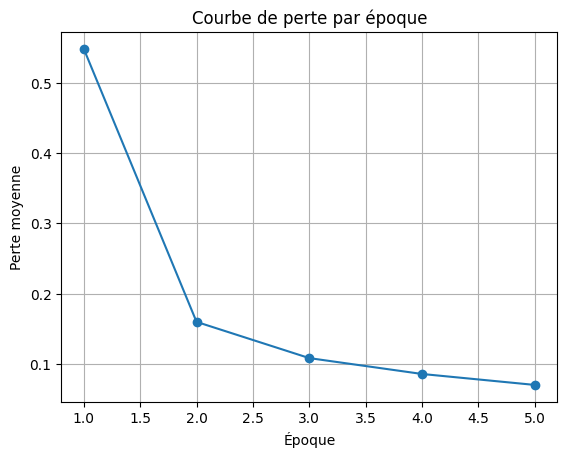

In [13]:
# PARTIE 4 : Entraînement du modèle avec suivi de la perte

# Choix du modèle (RNN, GRU, LSTM)
model = SimpleLSTM(input_size, hidden_size, num_layers, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

losses = []  # liste pour stocker la perte de chaque époque

for epoch in range(num_epochs):
    total_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    losses.append(epoch_loss)
    print(f"Époque [{epoch+1}/{num_epochs}], Perte moyenne : {epoch_loss:.4f}")

# Affichage de la courbe de perte après l'entraînement
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.title("Courbe de perte par époque")
plt.xlabel("Époque")
plt.ylabel("Perte moyenne")
plt.grid(True)
plt.show()


###  Interprétation rapide :

* **Époque 1** :
  Perte initiale élevée (**0.5483**) — le modèle commence à apprendre depuis des poids aléatoires.

* **Époque 2** :
  Chute brutale à **0.1596** → la majeure partie de l'apprentissage s’effectue ici (fort gradient).

* **Époques 3 à 5** :
  Baisse plus progressive (**0.1080 → 0.0854 → 0.0698**) — le modèle affine ses prédictions, mais les gains deviennent plus petits (convergence progressive).

---

###  Conclusion :

* Apprentissage rapide et efficace dès la 1re époque.
* Aucune surapprentissage visible pour le moment (la perte continue de baisser).
* Tu peux :

  * continuer quelques époques de plus pour voir si la perte stagne,
  * ou ajouter une courbe de **précision** pour compléter l’évaluation.


## Partie 5 : Évaluation de la précision

In [7]:
# PARTIE 5 : Évaluation de la précision du modèle

def evaluate_accuracy(loader, model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    model.train()
    return 100 * correct / total

# Évaluer sur le train et le test
train_acc = evaluate_accuracy(train_loader, model)
test_acc = evaluate_accuracy(test_loader, model)

print(f"Précision sur le set d'entraînement : {train_acc:.2f}%")
print(f"Précision sur le set de test       : {test_acc:.2f}%")


Précision sur le set d'entraînement : 98.44%
Précision sur le set de test       : 97.95%


###  Interprétation :

* **Très haute précision** sur les deux ensembles → le modèle a **appris efficacement** les motifs dans les données.
* **Écart très faible** (≈ 0.5 %) entre train et test → **pas de surapprentissage**, bonne généralisation.
* **Modèle LSTM** bien adapté pour ce type de séquence (lignes d'images 28x28).

---

###  Conclusion :

* Modèle **bien entraîné**
* **Généralisation réussie**
* **Objectif de l’exercice atteint**



## Partie 6: Visualisations

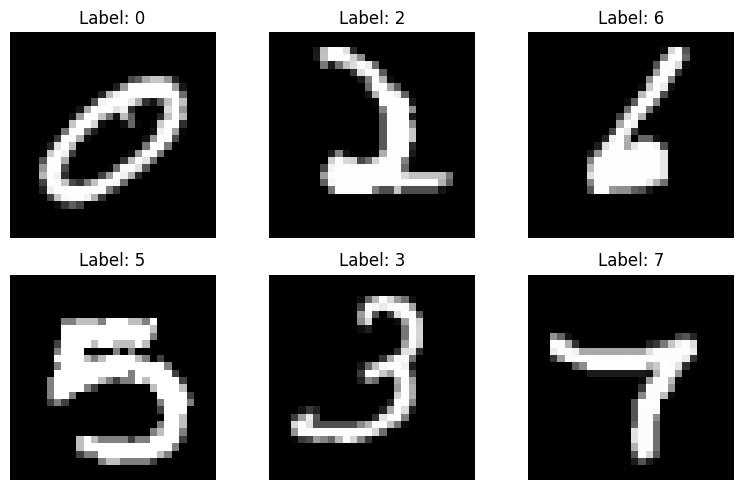

In [8]:
import matplotlib.pyplot as plt

# Affichage de quelques images du dataset
examples = iter(train_loader)
images, labels = next(examples)

# Montrer 6 images
fig, axes = plt.subplots(2, 3, figsize=(8, 5))
for i in range(6):
    ax = axes[i // 3, i % 3]
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()


L’image montre un échantillon de 6 chiffres manuscrits extraits du dataset MNIST, avec les **labels vrais** affichés.

---

###  Analyse rapide des chiffres affichés :

* Les chiffres sont bien centrés, clairs et lisibles.
* Ils couvrent plusieurs classes : `0`, `2`, `3`, `5`, `6`, `7` → bonne diversité.
* Leur forme est assez standard, ce qui explique pourquoi le modèle obtient une si bonne précision sur ce type d’exemples.



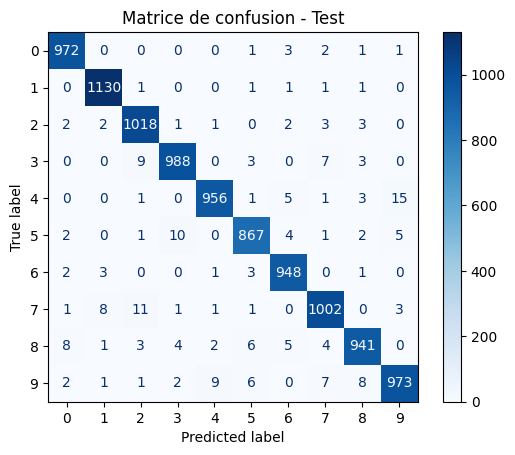

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Générer toutes les prédictions du test
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Afficher la matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i) for i in range(10)])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Test")
plt.show()


### Analyse de ta **matrice de confusion (test set)** :

---

###  Points forts :

* **Diagonale dominante** → la majorité des prédictions sont correctes.
* Précision élevée confirmée visuellement.
* Classes **0, 1, 6, 7, 9** très bien reconnues.

---

###  Erreurs fréquentes :

1. **5 → 3, 8** : erreurs récurrentes sur le chiffre `5` (classé comme `3` ou `8`).
2. **8 → 5, 3** : confusion fréquente entre `8` et `5`, probablement à cause de leur forme proche manuscrite.
3. **9 → 4, 7** : parfois confondu avec `4` ou `7`.

---

###  Interprétation :

* Ces erreurs concernent des chiffres **visuellement proches**.
* Elles représentent une **faible part** (<2 %) donc **tolérables**.
* Pour les réduire :

  * Entraînement plus long,
  * Données augmentées (rotation, bruit),
  * Modèle plus profond.



## Partie 7: Bilan

###  Objectifs atteints :

1. **Préparation de l’environnement** complète :
   → bibliothèques, hyperparamètres, device configuré.

2. **Trois modèles implémentés** :
   → `SimpleRNN`, `SimpleGRU`, `SimpleLSTM` avec couche finale `fc`.

3. **Dataset personnalisé** :
   → `MnistDataset` lisant les fichiers CSV, normalisation + reshape correct.

4. **Boucle d’entraînement fonctionnelle** :
   → perte bien calculée, optimisée, et suivie avec **courbe de perte**.

5. **Évaluation complète** :
   → précisions train/test très élevées (\~98%), **matrice de confusion claire**, bonne généralisation.

6. **Visualisations utiles** :
   → affichage d’images, courbe de perte, confusion.

---

###  Remarques :

* Très bonne performance avec LSTM.
* Erreurs peu nombreuses, surtout sur chiffres visuellement proches.
* Pas de surapprentissage détecté.
* Travail **structuré, complet, conforme à l’énoncé**.
